In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [3]:
from scipy import stats

In [4]:
from functions import preproc_funcs as funcs

In [33]:
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
# import mpatches
import matplotlib.patches as mpatches


In [7]:
import regionmask

In [39]:
def plot_background(ax, draw_labels=False, draw_ipcc_regions=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    if draw_ipcc_regions:
        ar6_reg = regionmask.defined_regions.ar6.all

        # Plot the region boundaries, passing the same 'ax'
        # Use 'line_kws' to customize line properties (color, thickness, etc.)
        ar6_reg.plot_regions(
            ax=ax,
            line_kws=dict(color='black', lw=1.0, alpha=0.4),
            text_kws=dict(fontsize=12, color='k'), # Set to True to add text labels for regions
            add_label=False, # Set to True to add text labels for regions
        )
    ax.tick_params(axis='both', labelsize=15)
    return ax




def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_not_equal(pval[i], 0)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='///', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] > 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_not_equal(pval[i], 1)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
                # pval_plot = xr.where(pval[i] <= 0.05, True, False)
                # axlist[i].scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker='.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.01, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return axlist



def plot_single_map(x, y, z, title, label, cmap, levels, add_sign=False, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, draw_ipcc_regions=False, auto_aspect=False, wind_separation=2):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    plot_background(ax, draw_labels=draw_labels, draw_ipcc_regions=draw_ipcc_regions)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = wind_separation
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        # qk = ax.quiverkey(q, X=0.85, Y=1.05, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        # qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if add_sign:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_not_equal(pval, 0)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='//', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval > 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_not_equal(pval, 1)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='..', transform = ccrs.PlateCarree(central_longitude=0))
            # pval_plot = xr.where(pval <= 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.01, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    
    return ax


# same as above but without projection for vertical structure map
# handle pvalue and stippling as well
def single_map_no_proj(x, y, z, title, label, cmap, levels, add_sign=False, pval = [], figsize=(12,4),  hatch_type = 'insig',
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True):

    fig, ax = plt.subplots(figsize=figsize)
    
    cf=ax.contourf(x, y, z, cmap = cmap, levels=levels, extend='both')
    # handle pvalue and stippling
    if add_sign:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_not_equal(pval, 0)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='//')
            # pval_plot = xr.where(pval > 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k')
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_not_equal(pval, 1)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...')
            # pval_plot = xr.where(pval <= 0.05, True, False)
            # ax.scatter(x[pval_plot.to_numpy()], y[pval_plot.to_numpy()], marker = '.', s=0.2, color='k')
    
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.01, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
                
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return ax

In [9]:
import cmocean

### load data

In [10]:
omega_cp_son = xr.open_dataset('./data/res/indiv_years/son/omega_cp.nc')
omega_ep_son = xr.open_dataset('./data/res/indiv_years/son/omega_ep.nc')
omega_neut_son = xr.open_dataset('./data/res/indiv_years/son/omega_neut.nc')

omega_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/omega_cp.nc')
omega_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/omega_ep.nc')
omega_neut_djf = xr.open_dataset('./data/res/indiv_years/djf/omega_neut.nc')

omega_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/omega_cp.nc')
omega_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/omega_ep.nc')
omega_neut_mam = xr.open_dataset('./data/res/indiv_years/mam/omega_neut.nc')

In [11]:
uwnd_levels_cp_son = xr.open_dataset('./data/res/indiv_years/son/uwnd_levels_cp.nc')
uwnd_levels_ep_son = xr.open_dataset('./data/res/indiv_years/son/uwnd_levels_ep.nc')
uwnd_levels_neut_son = xr.open_dataset('./data/res/indiv_years/son/uwnd_levels_neut.nc')

uwnd_levels_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/uwnd_levels_cp.nc')
uwnd_levels_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/uwnd_levels_ep.nc')
uwnd_levels_neut_djf = xr.open_dataset('./data/res/indiv_years/djf/uwnd_levels_neut.nc')

uwnd_levels_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/uwnd_levels_cp.nc')
uwnd_levels_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/uwnd_levels_ep.nc')
uwnd_levels_neut_mam = xr.open_dataset('./data/res/indiv_years/mam/uwnd_levels_neut.nc')

In [12]:
pres_cp_son = xr.open_dataset('./data/res/indiv_years/son/pres_cp.nc')
pres_ep_son = xr.open_dataset('./data/res/indiv_years/son/pres_ep.nc')
pres_neut_son = xr.open_dataset('./data/res/indiv_years/son/pres_neut.nc')

pres_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/pres_cp.nc')
pres_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/pres_ep.nc')
pres_neut_djf = xr.open_dataset('./data/res/indiv_years/djf/pres_neut.nc')

pres_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/pres_cp.nc')
pres_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/pres_ep.nc')
pres_neut_mam = xr.open_dataset('./data/res/indiv_years/mam/pres_neut.nc')

In [13]:
uwnd_cp_son = xr.open_dataset('./data/res/indiv_years/son/uwnd_cp.nc')
uwnd_ep_son = xr.open_dataset('./data/res/indiv_years/son/uwnd_ep.nc')

uwnd_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/uwnd_cp.nc')
uwnd_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/uwnd_ep.nc')

uwnd_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/uwnd_cp.nc')
uwnd_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/uwnd_ep.nc')

In [14]:
vwnd_cp_son = xr.open_dataset('./data/res/indiv_years/son/vwnd_cp.nc')
vwnd_ep_son = xr.open_dataset('./data/res/indiv_years/son/vwnd_ep.nc')

vwnd_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/vwnd_cp.nc')
vwnd_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/vwnd_ep.nc')

vwnd_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/vwnd_cp.nc')
vwnd_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/vwnd_ep.nc')

In [15]:
gz500_cp_son = xr.open_dataset('./data/res/indiv_years/son/gz500_cp.nc')
gz500_ep_son = xr.open_dataset('./data/res/indiv_years/son/gz500_ep.nc')
gz500_neut_son = xr.open_dataset('./data/res/indiv_years/son/gz500_neut.nc')

gz500_cp_djf = xr.open_dataset('./data/res/indiv_years/djf/gz500_cp.nc')
gz500_ep_djf = xr.open_dataset('./data/res/indiv_years/djf/gz500_ep.nc')
gz500_neut_djf = xr.open_dataset('./data/res/indiv_years/djf/gz500_neut.nc')

gz500_cp_mam = xr.open_dataset('./data/res/indiv_years/mam/gz500_cp.nc')
gz500_ep_mam = xr.open_dataset('./data/res/indiv_years/mam/gz500_ep.nc')
gz500_neut_mam = xr.open_dataset('./data/res/indiv_years/mam/gz500_neut.nc')

In [16]:
bstrap_pr_cp_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_son.nc')
bstrap_pr_ep_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_son.nc')

bstrap_pr_cp_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_djf.nc')
bstrap_pr_ep_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_djf.nc')

bstrap_pr_cp_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_cp_agreement_mask_mam.nc')
bstrap_pr_ep_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pr_ep_agreement_mask_mam.nc')

In [17]:
bstrap_omega_cp_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_cp_agreement_mask_son.nc')
bstrap_omega_ep_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_ep_agreement_mask_son.nc')

bstrap_omega_cp_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_cp_agreement_mask_djf.nc')
bstrap_omega_ep_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_ep_agreement_mask_djf.nc')

bstrap_omega_cp_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_cp_agreement_mask_mam.nc')
bstrap_omega_ep_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/omega_ep_agreement_mask_mam.nc')

In [18]:
bstrap_pres_cp_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_cp_agreement_mask_son.nc')
bstrap_pres_ep_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_ep_agreement_mask_son.nc')

bstrap_pres_cp_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_cp_agreement_mask_djf.nc')
bstrap_pres_ep_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_ep_agreement_mask_djf.nc')

bstrap_pres_cp_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_cp_agreement_mask_mam.nc')
bstrap_pres_ep_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/pres_ep_agreement_mask_mam.nc')

In [19]:
bstrap_gz500_cp_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_cp_agreement_mask_son.nc')
bstrap_gz500_ep_son = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_ep_agreement_mask_son.nc')

bstrap_gz500_cp_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_cp_agreement_mask_djf.nc')
bstrap_gz500_ep_djf = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_ep_agreement_mask_djf.nc')

bstrap_gz500_cp_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_cp_agreement_mask_mam.nc')
bstrap_gz500_ep_mam = xr.open_dataset('./data/res/LN_diversity_bootstrap_masks/gz500_ep_agreement_mask_mam.nc')

In [20]:
plot_list = [
    # son
    pres_cp_son.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pres_ep_son.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pres_cp_son.prmsl.mean('time') - pres_ep_son.prmsl.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # djf
    pres_cp_djf.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pres_ep_djf.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pres_cp_djf.prmsl.mean('time') - pres_ep_djf.prmsl.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # # mam
    pres_cp_mam.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    pres_ep_mam.prmsl.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # (pres_cp_mam.prmsl.mean('time') - pres_ep_mam.prmsl.mean('time')).sel(lat = slice(-55, 55), lon = slice(60, 330)),
]

In [21]:
pval_list = [
    # son
    bstrap_pres_cp_son.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pres_ep_son.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # bstrap_pres_cp_son.prmsl* bstrap_pres_ep_son.prmsl,
    # np.empty_like(bstrap_pres_cp_son.prmsl),
    # djf
    bstrap_pres_cp_djf.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pres_ep_djf.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # np.empty_like(bstrap_pres_cp_djf.prmsl),
    # # mam
    bstrap_pres_cp_mam.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    bstrap_pres_ep_mam.prmsl.sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # # bstrap_pres_cp_mam.prmsl * bstrap_pres_ep_mam.prmsl,
    # np.empty_like(bstrap_pres_cp_mam.prmsl),
]

In [22]:
uwnd_cp_djf

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 23, nbnds: 2, lat: 181, lon: 360)
Coordinates:
  * lat        (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon        (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time       (time) datetime64[ns] 184B 1903-06-01 1909-06-01 ... 2011-06-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 368B ...
    uwnd       (time, lat, lon) float32 6MB ...

In [23]:
uwnd_list = [
    #son
    uwnd_cp_son.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    uwnd_ep_son.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # djf
    uwnd_cp_djf.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    uwnd_ep_djf.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # mam
    uwnd_cp_mam.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    uwnd_ep_mam.uwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
]

vwnd_list = [
    #son
    vwnd_cp_son.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    vwnd_ep_son.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # djf
    vwnd_cp_djf.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    vwnd_ep_djf.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    # mam
    vwnd_cp_mam.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
    vwnd_ep_mam.vwnd.mean(dim='time').sel(lat = slice(-55, 55), lon = slice(60, 330)),
]

In [24]:
import cmocean


In [25]:
# xx, yy = np.meshgrid(pres_cp_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lon, pres_cp_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lat)

# axlist = plot_maps(xx, yy, plot_list, 
#           titles=['CP La Niña','EP La Niña'#,'CP - EP La Niña',
#                   '','','',
#                   '','',''],
#           labels=['a','b','c','d','e','f'],#,'g','h','i'],
#           cmap='BrBG',
#           levels=np.linspace(-2.0, 2.0, 21),
#           pval=pval_list,
#           hatch_type='sig',
#           nrows=3,
#           ncols=2,
#           figsize=(12,8),
#           cbar_kwargs=dict(orientation='vertical', label='Precipitation Rate (mm/day)', aspect=40, shrink=0.7, pad=0.05),
#           draw_labels=False,
#           proj=ccrs.PlateCarree(central_longitude=160),
#           land_mask_list=[],
#           draw_ipcc_regions=True,
#           auto_aspect=True,
#           )
    

# # change each subplot extent to focus on the region of interest defined above
# for ax in axlist:
#     ax.set_extent([60, 330, -55, 55], crs=ccrs.PlateCarree())

# # add DJF, MAM and SON labels to the left of the rows
# # plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.3, wspace=0.2)
# # plt.figtext(0.10, 0.75, 'SON', fontsize=16, fontweight='bold', rotation='vertical')
# # plt.figtext(0.10, 0.48, 'DJF', fontsize=16, fontweight='bold', rotation='vertical')
# # plt.figtext(0.10, 0.2, 'MAM', fontsize=16, fontweight='bold', rotation='vertical')

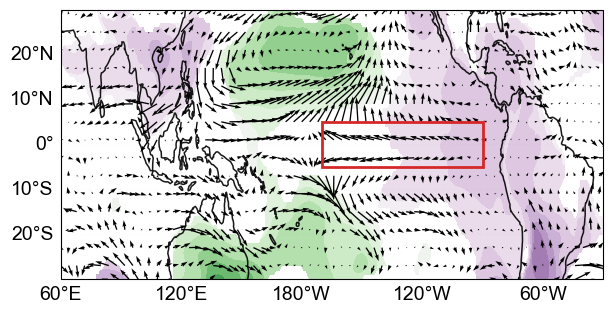

In [45]:
# plot a single map for ep La Niña in SON with wind vectors and color of green purple and hatching for significance
# can we change the orientation of the image so that it feels like it is bottom of a cube?
xx, yy = np.meshgrid(pres_ep_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lon, pres_ep_son.sel(lat = slice(-55, 55), lon = slice(60, 330)).lat)
ax = plot_single_map(xx, yy, plot_list[5].where(pval_list[5] == 1), 
          title='',
          label='',
          cmap='PRGn_r',
          levels=np.linspace(-200.0, 200.0, 21),
          add_sign=False,
          pval=pval_list[5],
          hatch_type='sig',
          draw_winds=True,
          u_wnd=uwnd_list[5],
          v_wnd=vwnd_list[5],
          wind_scale=30,
          figsize=(7,3.5),
          cbar_kwargs=dict(orientation='vertical', label='Mean Sea Level Pressure (hPa)', aspect=40, shrink=0.9, pad=0.05),
          draw_labels=True,
          proj=ccrs.PlateCarree(central_longitude=160),
          land_mask_list=False,
          draw_ipcc_regions=False,
          auto_aspect=True,
          draw_colorbar=False,
          wind_separation=4
          )
# change subplot extent to focus on the region of interest defined above
ax.set_extent([60, 330, -30, 30], crs=ccrs.PlateCarree())
# draw a box with the nino34 region only
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='tab:red', lw=2,
                                transform=ccrs.PlateCarree()))

In [110]:
# import scalarformatter
from matplotlib.ticker import ScalarFormatter

In [111]:
pval_list

[<xarray.DataArray 'prmsl' (lat: 111, lon: 271)> Size: 241kB
 array([[0., 0., 0., ..., 1., 1., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]])
 Coordinates:
   * lat      (lat) float32 444B -55.0 -54.0 -53.0 -52.0 ... 52.0 53.0 54.0 55.0
   * lon      (lon) float32 1kB 60.0 61.0 62.0 63.0 ... 327.0 328.0 329.0 330.0,
 <xarray.DataArray 'prmsl' (lat: 111, lon: 271)> Size: 241kB
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.]])
 Coordinates:
   * lat      (lat) float32 444B -55.0 -54.0 -53.0 -52.0 ... 52.0 53.0 54.0 55.0
   * lon      (lon) float32 1kB 60.0 61.0 62.0 63.0 ... 327.0 328.0 329.0 330.0,
 <xarray.DataArray 'prmsl' (la

[]

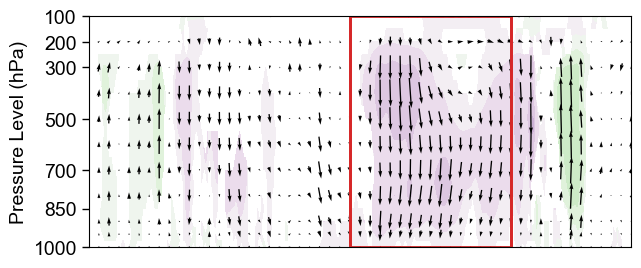

In [113]:
# plot a figure with the omega value with the vectors having omega and uwnd at levels to show vertical motion, 
# note that omega and uwnd_levels are already in levels and lon dimensions so we don't need to slice for lat, but only lon
# note we don't want the projection
# uwnd_levels and omega have different levels range so let's slice them to match
# scale the vectors appropriately to show the vertical motion and match the size of the figure above
omega_mam_ep_plot = omega_ep_mam.omega.sel(lon = slice(60, 330)).mean(dim='time')
bstrap_mam_ep_plot = bstrap_omega_ep_mam.omega.sel(lon = slice(60, 330))
uwnd_levels_mam_ep_plot = uwnd_levels_ep_mam.uwnd.sel(level = omega_mam_ep_plot.level, lon = slice(60, 330)).mean(dim='time')
xx, yy = np.meshgrid(omega_mam_ep_plot.lon, omega_mam_ep_plot.level)
omega_mam_ep_plot = omega_mam_ep_plot.transpose('level', 'lon')
ax2 = single_map_no_proj(xx, yy, omega_mam_ep_plot.where(bstrap_mam_ep_plot == 1),
          title='',
          label='',
          cmap='PRGn_r',
          levels=np.linspace(-0.04, 0.04, 21),
          add_sign=False,
          pval = bstrap_mam_ep_plot.transpose('level', 'lon'),
          hatch_type='sig',
          figsize=(7,3),
          cbar_kwargs=dict(orientation='vertical', label='Vertical Velocity (Pa/s)', aspect=40, shrink=0.9, pad=0.05),
          draw_colorbar=False,
          )
# add quiver vectors
wind_separation_z = 5
wind_separation_u = 2
# the vectors are too small so we need to scale them up for visibility
q = ax2.quiver(xx[::wind_separation_u, ::wind_separation_z], yy[::wind_separation_u, ::wind_separation_z], uwnd_levels_mam_ep_plot.to_numpy()[::wind_separation_u, ::wind_separation_z], (-omega_mam_ep_plot * 1000).to_numpy()[::wind_separation_u, ::wind_separation_z], scale=200, color='k', pivot='middle') # scale adjusted for visibility
# qk = ax2.quiverkey(q, X=0.70, Y=1.05, U=5.0, label='5 m/s, 0.01 Pa/s', labelpos='E', coordinates='axes')
# qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
# invert y axis to have pressure decreasing upwards
ax2.invert_yaxis()
# set y axis to log scale
# ax2.set_yscale('log')
# set y axis ticks to standard pressure levels
ax2.set_yticks([1000, 850, 700, 500, 300, 200, 100])
ax2.get_yaxis().set_major_formatter(ScalarFormatter())
ax2.set_ylabel('Pressure Level (hPa)')
# set x axis to show lon from 60 to 330
ax2.set_xlim(60, 330)
# highlight the nino34 region with a rectangle
ax2.axvline(x=190, color='tab:red', lw=2)
ax2.axvline(x=270, color='tab:red', lw=2)
ax2.fill_betweenx(y=[1000, 100], x1=190, x2=270, color='none', edgecolor='tab:red', lw=2)
# don't show x axis ticks
ax2.set_xticks([])